In [1]:
!pip install sentence-transformers scikit-learn pandas numpy matplotlib seaborn

In [2]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

## Configuration
- **`SIMILARITY_THRESHOLD`** — minimum cosine similarity for two entries to be linked in the similarity graph. Connected components of this graph form the base clusters.  
- **`EXPANSION_THRESHOLD`** — during the overlap phase, minimum similarity an entry must have to *each* cluster member it is checked against.  
- **`EXPANSION_MEMBER_RATIO`** — fraction of a cluster's members an entry must be similar to (at `EXPANSION_THRESHOLD`) in order to join that cluster as an additional membership.  
- **`MAX_CLUSTER_SIZE`** — hard cap; oversized connected components are split, and expansion never exceeds this limit.  

Lower `SIMILARITY_THRESHOLD` → fewer, larger components. Lower `EXPANSION_THRESHOLD` / `EXPANSION_MEMBER_RATIO` → more multi-cluster memberships. Raise `MAX_CLUSTER_SIZE` to allow bigger groups.  
Entries can belong to **multiple** clusters (via the expansion phase).

In [40]:
SIMILARITY_THRESHOLD = 0.65
EXPANSION_THRESHOLD = 0.55
EXPANSION_MEMBER_RATIO = 0.55
MAX_CLUSTER_SIZE = 12

IDEAS_PATH = '/content/drive/MyDrive/intellexus/intellexus_ideas_01.json'
OUTPUT_PATH = '/content/drive/MyDrive/intellexus/intellexus_ideas_resolved.json'

MODEL_NAME = 'sentence-transformers/all-MiniLM-L6-v2'

## Load Data

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
with open(IDEAS_PATH, 'r') as f:
    ideas_raw = json.load(f)

if isinstance(ideas_raw, list):
    ideas_df = pd.json_normalize(ideas_raw)
elif isinstance(ideas_raw, dict):
    ideas_df = pd.DataFrame.from_dict(ideas_raw, orient='index').T

print(f'Loaded {len(ideas_df)} entries')
ideas_df.head()

Loaded 413 entries


,entities,relationships
0,"{'name': '""Ordinary worldly views perceive int...","{'source': '""Ordinary worldly views perceive i..."
1,"{'name': '""dngos po gsum""', 'entity_type': '""e...","{'source': '""The view of self is based on a la..."
2,"{'name': '""The view of self is based on a lack...","{'source': '""The self is perceived as an agent..."
3,"{'name': '""Ordinary beings have held the unexa...","{'source': '""The view of self is based on a la..."
4,"{'name': '""The self is perceived as a single, ...","{'source': '""The self is perceived as a single..."


## Encode Entities

In [6]:
model = SentenceTransformer(MODEL_NAME)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [7]:
def build_text(entry: dict) -> str:
    entity = entry['entities']
    name = entity['name']
    etype = entity['entity_type']
    desc = entity['description']
    return f'{desc}'

ideas_df['text'] = ideas_df.apply(build_text, axis=1)
ideas_df[['text']].head()

,text
0,"""The perspective of common worldly beings (pṛt..."
1,"""The triad of entities consisting of the self ..."
2,"""The innate grasping at a self occurs without ..."
3,"""Sentient beings have possessed an unanalyzed,..."
4,"""The erroneous view that the self is a unitary..."


In [8]:
embeddings = model.encode(ideas_df['text'].tolist(), show_progress_bar=True, normalize_embeddings=True)

Batches:   0%|          | 0/13 [00:00<?, ?it/s]

## Cosine Similarity Matrix

In [9]:
sim_matrix = cosine_similarity(embeddings)
np.fill_diagonal(sim_matrix, 0)

print(f'Similarity matrix shape: {sim_matrix.shape}')
print(f'Mean pairwise similarity: {sim_matrix[np.triu_indices_from(sim_matrix, k=1)].mean():.4f}')
print(f'Max pairwise similarity:  {sim_matrix.max():.4f}')

Similarity matrix shape: (413, 413)
Mean pairwise similarity: 0.3717
Max pairwise similarity:  0.9792


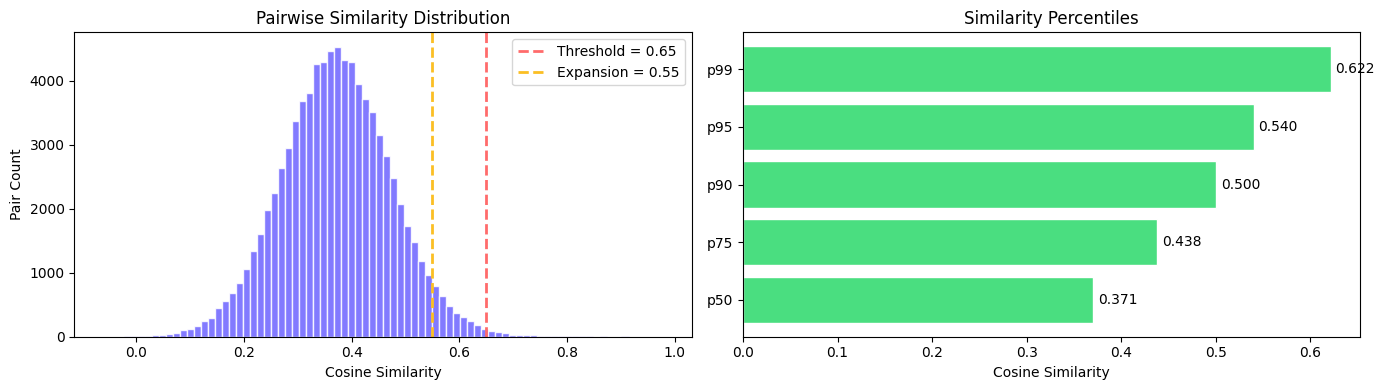

Pairs above threshold (0.65): 468 / 85,078 (0.55%)
Pairs above expansion (0.55): 3,534 / 85,078


In [41]:
upper_tri = sim_matrix[np.triu_indices_from(sim_matrix, k=1)]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(upper_tri, bins=80, edgecolor='white', color='#6c63ff', alpha=0.85)
axes[0].axvline(SIMILARITY_THRESHOLD, color='#ff6b6b', linestyle='--', linewidth=2, label=f'Threshold = {SIMILARITY_THRESHOLD}')
axes[0].axvline(EXPANSION_THRESHOLD, color='#fbbf24', linestyle='--', linewidth=2, label=f'Expansion = {EXPANSION_THRESHOLD}')
axes[0].set_xlabel('Cosine Similarity')
axes[0].set_ylabel('Pair Count')
axes[0].set_title('Pairwise Similarity Distribution')
axes[0].legend()

percentiles = [50, 75, 90, 95, 99]
pct_values = np.percentile(upper_tri, percentiles)
axes[1].barh([f'p{p}' for p in percentiles], pct_values, color='#4ade80', edgecolor='white')
axes[1].set_xlabel('Cosine Similarity')
axes[1].set_title('Similarity Percentiles')
for i, v in enumerate(pct_values):
    axes[1].text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

pairs_above = (upper_tri >= SIMILARITY_THRESHOLD).sum()
total_pairs = len(upper_tri)
print(f'Pairs above threshold ({SIMILARITY_THRESHOLD}): {pairs_above:,} / {total_pairs:,} ({100*pairs_above/total_pairs:.2f}%)')
print(f'Pairs above expansion ({EXPANSION_THRESHOLD}): {(upper_tri >= EXPANSION_THRESHOLD).sum():,} / {total_pairs:,}')

## Entity Resolution — Overlapping Clustering
**Phase 1 — Components:** build a similarity graph (edges where sim ≥ `SIMILARITY_THRESHOLD`) and find connected components.  
**Phase 2 — Split:** components larger than `MAX_CLUSTER_SIZE` are split into sub-clusters by greedily picking the most-connected seed and its top similar neighbours.  
**Phase 3 — Expand (overlap):** every entry (assigned or not) can join additional clusters if similar (≥ `EXPANSION_THRESHOLD`) to at least `EXPANSION_MEMBER_RATIO` of a cluster's members. This is the only phase that creates multi-cluster membership.  
Clusters are capped at `MAX_CLUSTER_SIZE`.

In [42]:
def resolve_entities(sim_matrix, threshold, expansion_threshold,
                     expansion_member_ratio, max_cluster_size):
    n = len(sim_matrix)

    # --- Build neighbour graph ---
    neighbors = defaultdict(set)
    for i in range(n):
        for j in range(i + 1, n):
            if sim_matrix[i, j] >= threshold:
                neighbors[i].add(j)
                neighbors[j].add(i)

    # --- Phase 1: Connected components ---
    visited = set()
    components = []
    for node in range(n):
        if node in visited or not neighbors[node]:
            continue
        comp = set()
        stack = [node]
        while stack:
            curr = stack.pop()
            if curr in visited:
                continue
            visited.add(curr)
            comp.add(curr)
            for nb in neighbors[curr]:
                if nb not in visited:
                    stack.append(nb)
        if len(comp) >= 2:
            components.append(comp)

    # --- Phase 2: Split oversized components ---
    clusters = []
    for comp in components:
        if len(comp) <= max_cluster_size:
            clusters.append(frozenset(comp))
            continue

        remaining = set(comp)
        while remaining:
            if len(remaining) <= max_cluster_size:
                if len(remaining) >= 2:
                    clusters.append(frozenset(remaining))
                remaining = set()
                break

            seed = max(remaining, key=lambda x: sum(
                1 for nb in neighbors[x] if nb in remaining
            ))
            candidates = sorted(
                [j for j in remaining if j != seed and sim_matrix[seed, j] >= threshold],
                key=lambda j: sim_matrix[seed, j],
                reverse=True,
            )[:max_cluster_size - 1]

            sub = frozenset({seed} | set(candidates))
            clusters.append(sub)
            remaining -= sub

    # --- Phase 3: Expand — member-wise overlap (all entries checked) ---
    expanded = [set(c) for c in clusters]

    if expansion_threshold is not None and expansion_threshold > 0:
        for idx in range(n):
            for cid, cluster in enumerate(clusters):
                if idx in cluster:
                    continue
                if len(expanded[cid]) >= max_cluster_size:
                    continue
                members = list(cluster)
                above = sum(1 for m in members if sim_matrix[idx, m] >= expansion_threshold)
                if members and above / len(members) >= expansion_member_ratio:
                    expanded[cid].add(idx)

    clusters = [frozenset(c) for c in expanded]

    # --- Build mapping ---
    entry_to_clusters = defaultdict(list)
    for cid, cluster in enumerate(clusters):
        for entry in cluster:
            entry_to_clusters[entry].append(cid)

    for i in range(n):
        if i not in entry_to_clusters:
            entry_to_clusters[i] = [-1]

    return clusters, dict(entry_to_clusters)


clusters, entry_to_clusters = resolve_entities(
    sim_matrix,
    threshold=SIMILARITY_THRESHOLD,
    expansion_threshold=EXPANSION_THRESHOLD,
    expansion_member_ratio=EXPANSION_MEMBER_RATIO,
    max_cluster_size=MAX_CLUSTER_SIZE,
)

ideas_df['cluster_ids'] = [entry_to_clusters[i] for i in range(len(ideas_df))]
ideas_df['primary_cluster'] = ideas_df['cluster_ids'].apply(lambda x: x[0])

n_clustered = sum(1 for v in entry_to_clusters.values() if v != [-1])
n_multi = sum(1 for v in entry_to_clusters.values() if len(v) > 1)
print(f'Sim threshold:         {SIMILARITY_THRESHOLD}')
print(f'Expansion threshold:   {EXPANSION_THRESHOLD}')
print(f'Expansion member ratio:{EXPANSION_MEMBER_RATIO}')
print(f'Max cluster size:      {MAX_CLUSTER_SIZE}')
print(f'Clusters found:        {len(clusters)}')
print(f'Entries in clusters:   {n_clustered} / {len(ideas_df)}')
print(f'Multi-cluster entries: {n_multi}')
print(f'Unclustered (noise):   {len(ideas_df) - n_clustered}')

Sim threshold:         0.65
Expansion threshold:   0.55
Expansion member ratio:0.55
Max cluster size:      12
Clusters found:        80
Entries in clusters:   307 / 413
Multi-cluster entries: 152
Unclustered (noise):   106


## Inspect Clusters

In [43]:
for cid, members in enumerate(clusters):
    members_sorted = sorted(members)
    names = ideas_df.loc[members_sorted, 'text'].tolist()
    within_sims = []
    ml = list(members_sorted)
    for a in range(len(ml)):
        for b in range(a + 1, len(ml)):
            within_sims.append(sim_matrix[ml[a], ml[b]])
    avg_sim = np.mean(within_sims) if within_sims else 0.0
    print(f'\n--- Cluster {cid} ({len(members)} members, avg similarity {avg_sim:.3f}) ---')
    for name in names:
        print(f'  • {name[:700]}')


--- Cluster 0 (12 members, avg similarity 0.654) ---
  • The view that the Buddha's realization is beyond material form, consisting of omniscient pure worldly wisdom (śuddhalaukikajñāna) without actual sensory contact.
  • "The assertion that Buddhas are endowed with six types of bliss (ṣaḍdharmasukha) encompassing pure reality, wisdom, the rūpakāya, and mental/physical bliss arising from merit."
  • "The six dharmas of bliss, encompassing cognitive, ontological, and physical aspects of a Buddha's experience."
  • "The collective category of the three types of bliss experienced by a Buddha, specifically sensory bliss, the bliss of the natural body, and the bliss of the mind."
  • "The collective category of the four types of bliss experienced by a Buddha."
  • "The proposition that the Buddha experiences sensory bliss (from forms and sounds), the bliss of the natural body (svābhāvikakāya) resulting from virtuous roots, and the mental bliss of perceiving the unconditioned reality (dhar

## Visualisation

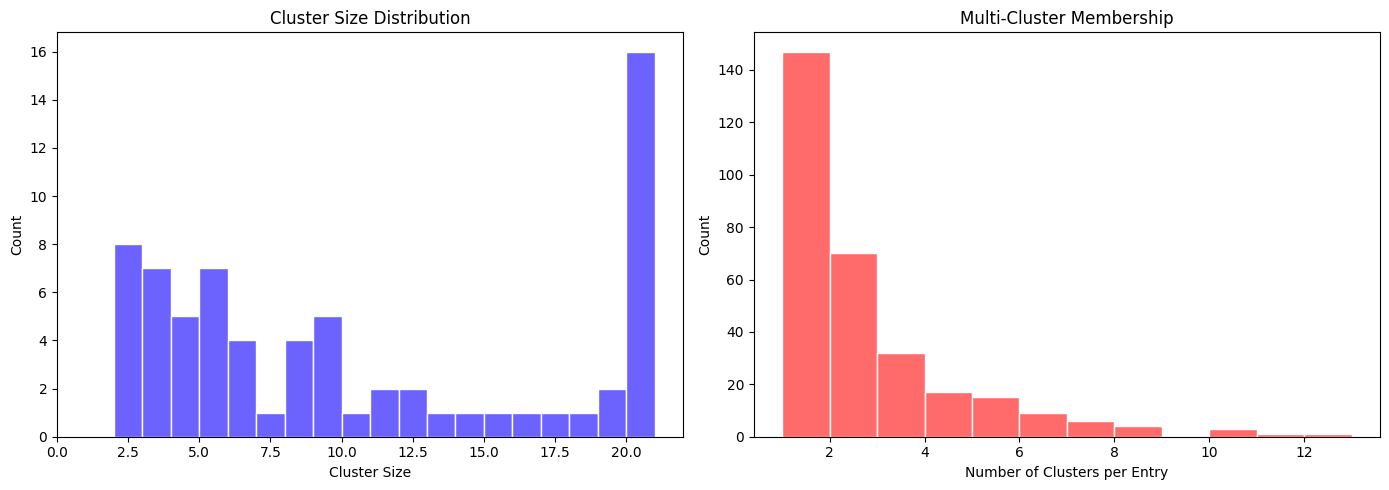

In [37]:
cluster_sizes = [len(c) for c in clusters]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(cluster_sizes, bins=range(1, max(cluster_sizes) + 2), edgecolor='white', color='#6c63ff')
axes[0].set_xlabel('Cluster Size')
axes[0].set_ylabel('Count')
axes[0].set_title('Cluster Size Distribution')

memberships = [len(v) for v in entry_to_clusters.values() if v != [-1]]
if memberships:
    axes[1].hist(memberships, bins=range(1, max(memberships) + 2), edgecolor='white', color='#ff6b6b')
    axes[1].set_xlabel('Number of Clusters per Entry')
    axes[1].set_ylabel('Count')
    axes[1].set_title('Multi-Cluster Membership')

plt.tight_layout()
plt.show()

In [38]:
if len(clusters) <= 30:
    cluster_centroids = np.array([
        embeddings[list(c)].mean(axis=0) for c in clusters
    ])
    centroid_sim = cosine_similarity(cluster_centroids)

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        centroid_sim,
        annot=True, fmt='.2f', cmap='RdYlGn',
        xticklabels=[f'C{i}' for i in range(len(clusters))],
        yticklabels=[f'C{i}' for i in range(len(clusters))],
    )
    plt.title('Inter-Cluster Centroid Similarity')
    plt.tight_layout()
    plt.show()
else:
    print(f'{len(clusters)} clusters — skipping heatmap (too large). Lower the threshold for fewer clusters.')

70 clusters — skipping heatmap (too large). Lower the threshold for fewer clusters.


## Save Resolved Dataset

In [ ]:
def save_resolved_dataset(df, clusters, output_path, fmt='json'):
    out = df.copy()
    out['cluster_ids'] = out['cluster_ids'].apply(json.dumps)

    if fmt == 'json':
        records = []
        for _, row in out.iterrows():
            rec = row.to_dict()
            rec['cluster_ids'] = json.loads(rec['cluster_ids'])
            records.append(rec)
        with open(output_path, 'w') as f:
            json.dump(records, f, indent=2, default=str)
    elif fmt == 'csv':
        out.to_csv(output_path, index=False)
    elif fmt == 'parquet':
        out.to_parquet(output_path, index=False)
    else:
        raise ValueError(f'Unsupported format: {fmt}')

    print(f'Saved {len(df)} entries ({len(clusters)} clusters) to {output_path}')


save_resolved_dataset(ideas_df, clusters, OUTPUT_PATH, fmt='json')